# Završni projektni zadatak: Analiza podataka za smanjenje ugljičnog otiska Republike Hrvatske

## Sažetak
Projekt analizira klimatske podatke (osunčanost i brzina vjetra) za 10
hrvatskih gradova kako bi identificirao optimalne lokacije za postavljanje
solarnih i vjetroelektrana. Cilj je procijeniti potencijal smanjenja
emisija CO₂ u energetskom sektoru koji je trenutno odgovoran za ~50%
nacionalnih emisija.

## Problem koji se rješava
Hrvatska ima ambiciozan cilj biti klimatski neutralna do 2050. Obnovljivi
izvori energije su ključni za postizanje ovog cilja. Zato, njihova
isplativost ovisi o lokalnim klimatskim uvjetima koje ću analizirati u ovom radu.

## Metodološki pristup
Analiza koristi dva kriterija:
- **Osunčanost**: > 2400 sati godišnje (kritična za solarne elektrane)
- **Brzina vjetra**: > 4.5 m/s (minimalna za ekonomsku isplativost vjetroelektrana)


Prvi koraj u projektu je uvoz sljedećih biblioteka

In [ ]:
import requests
from bs4 import BeautifulSoup

import pandas as pd
import numpy as np

import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point

import warnings
warnings.filterwarnings('ignore')

Opis metodologije

Podaci su prikupljeni automatiziranim "scrapingom" sa službenih stranica DHMZ-a. Za procjenu energetske učinkovitosti korišteni su standardni koeficijenti za RH (0.23 kg CO2/kWh). Analiza se fokusira na gradove s preko 2400 sunčanih sati godišnje te lokacije s prosječnom brzinom vjetra iznad 4.5 m/s kao pragom isplativosti.

In [ ]:
gradovi = [
    "dubrovnik", "bjelovar", "gospic", "pula",
    "osijek", "rijeka", "split_marjan", "komiza",
    "zadar", "zagreb_maksimir"
]

svi_podaci = {}

print("Započinjem prikupljanje podataka...")

for grad in gradovi:
    url = f"https://meteo.hr/klima.php?section=klima_podaci&param=k1&Grad={grad}"
    try:
        page = requests.get(url)
        soup = BeautifulSoup(page.text, "html.parser")

        tablica = soup.find("table", {"class": "table--aktualni-podaci"})

        if tablica:
            rows = tablica.find_all("tr")
            data = []
            headers = [header.text.strip() for header in rows[0].find_all("th")]

            for row in rows[1:]:
                columns = row.find_all(["th", "td"])
                data.append([col.text.strip() for col in columns])

            df = pd.DataFrame(data, columns=headers)
            svi_podaci[grad] = df
            print(f"Uspješno prikupljeni podaci za: {grad}")
        else:
            print(f"Tablica nije pronađena za: {grad}")

    except Exception as e:
        print(f"Greška kod grada {grad}: {e}")

print("\nPrimjer podataka za Dubrovnik:")
display(svi_podaci['dubrovnik'].iloc[[7]])

Započinjem prikupljanje podataka...
Uspješno prikupljeni podaci za: dubrovnik
Uspješno prikupljeni podaci za: bjelovar
Uspješno prikupljeni podaci za: gospic
Uspješno prikupljeni podaci za: pula
Uspješno prikupljeni podaci za: osijek
Uspješno prikupljeni podaci za: rijeka
Uspješno prikupljeni podaci za: split_marjan
Uspješno prikupljeni podaci za: komiza
Uspješno prikupljeni podaci za: zadar
Uspješno prikupljeni podaci za: zagreb_maksimir

Primjer podataka za Dubrovnik:


,,siječanj,veljača,ožujak,travanj,svibanj,lipanj,srpanj,kolovoz,rujan,listopad,studeni,prosinac
7,Suma [sati],130.9,142.5,181.1,214.5,270.6,309.4,350.9,332.7,254.7,201.6,132.2,119.9


In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('projekti.db')
cursor = conn.cursor()

In [ ]:

def kreiraj_tablicu_klima(cursor):
    cursor.execute('DROP TABLE IF EXISTS klima')
    cursor.execute('''
    CREATE TABLE klima (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        lokacija TEXT,
        brzina_vjetra REAL,
        suncani_sati_godisnje REAL
    )
    ''')



**UPIT AI-ju**
Za ovaj dio koda o procjenama vjetra nisam uspio naći podatke u obliku u kojem bih ih mogao implementirati kao na primjer tablicu sa gradovima pa sam pitao umjetnu inteligenciju da mi da izvor i procjenu vjetrova za gradove koje sam odabrao, ovo je moj prompt prema Chat-GPTju:

**PROMPT**
ajde reci daj neke javno dostupne podatke za procjenu vjetra u sljedećim hrvatskim gradovima - Duborvnik, Split, Komiža, Zadar, Rijeja, Gospić, Osijek, Zagreb, Pula i Bjelovar. Koji bi bio izvor za ove gradove? Daj mi odgovor za ovja prompt u 5 6 recenica bez ikakvih stickera i natuknica tako da ovaj tvoj odgovor mogu staviti profesoru kao odgovor na pitanje odakle mi ovu podaci

**ODGOVOR CHATGP-JA**
Vrijednosti prosječne brzine vjetra po lokacijama preuzete su iz kombinacije javno dostupnih meteoroloških i klimatskih izvora, prvenstveno podataka Državnog hidrometeorološkog zavoda (DHMZ) i njegovog Wind Atlasa Hrvatske, koji prikazuje prostornu raspodjelu prosječnih brzina vjetra na standardnim visinama mjerenja. Dodatno su korišteni klimatski podaci meteoroloških postaja objavljeni na meteo.hr, gdje su dostupne dugogodišnje statistike meteoroloških parametara za pojedine gradove i postaje. U slučajevima gdje izravni prosjeci nisu bili dostupni u tabličnom obliku, vrijednosti su aproksimirane na temelju raspona prikazanih na kartama i statističkim izvještajima. Takav pristup omogućuje dobivanje realističnih i usporedivih procjena potencijala vjetra za različite lokacije u Hrvatskoj. Iako su vrijednosti djelomično zaokružene radi jednostavnije analize, one se temelje na stvarnim klimatskim podacima i služe kao reprezentativan pokazatelj potencijala za razvoj vjetroelektrana u okviru ovog projekta.

In [ ]:
procjene_vjetra = {
    "dubrovnik": 5.4, "split_marjan": 5.4, "komiza": 5.8, "zadar": 4.8,
    "rijeka": 5.0, "gospic": 4.1, "osijek": 3.2, "zagreb_maksimir": 2.7,
    "pula": 4.2, "bjelovar": 2.4
}

In [ ]:
def izracunaj_suncane_sate(df_grad, grad):
    red_suma = df_grad[df_grad.iloc[:, 0].str.contains("Suma", na=False)]

    if not red_suma.empty:
        vrijednosti = red_suma.iloc[0, 1:].replace('', '0').astype(float)
        return vrijednosti.sum()
    else:
        return 2400.0 if grad in ["pula", "komiza"] else 2000.0


def pripremi_podatke_klima(gradovi, svi_podaci, procjene_vjetra):
    podaci = []

    for grad in gradovi:
        df_grad = svi_podaci[grad]
        suma_sati = izracunaj_suncane_sate(df_grad, grad)

        vjetar = procjene_vjetra.get(grad, None)
        podaci.append((grad.capitalize(), vjetar, suma_sati))

    return podaci


In [ ]:

def ubaci_podatke_klima(cursor, podaci_za_bazu):
    cursor.executemany(
        'INSERT INTO klima (lokacija, brzina_vjetra, suncani_sati_godisnje) VALUES (?, ?, ?)',
        podaci_za_bazu
    )


In [ ]:
def kreiraj_tablicu_ugljik(cursor):
    cursor.execute('DROP TABLE IF EXISTS ugljik')
    cursor.execute('''
    CREATE TABLE ugljik (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        godina INTEGER,
        ukupna_emisija REAL,
        sektor TEXT,
        emisija_energetski_sektor REAL
    )
    ''')


**UPIT AI-JU ZA PODATKE O UGLJIKU**

Kao i za podatke o procjeni vjetra, podatke o ugljiku kroz zadnjih 5 godina sam pitao umjetnu inteligenciju, moj prompt je bio sličan kao i u prethondom primjeru a evo kompletnog odgovora AI-ja

**ODOGOVOR AI-JA**
Podaci o ukupnim emisijama CO₂ i emisijama energetskog sektora temeljeni su na javno dostupnim nacionalnim i europskim statističkim izvorima, prvenstveno izvješćima Državnog zavoda za statistiku Republike Hrvatske (DZS) te inventarima emisija koje objavljuju Ministarstvo gospodarstva i održivog razvoja. Dodatno su korišteni agregirani podaci Europske agencije za okoliš (EEA) i međunarodnih baza poput UNFCCC i Our World in Data, koje pružaju vremenske serije emisija stakleničkih plinova po državama i sektorima. Konkretne numeričke vrijednosti u projektu predstavljaju aproksimirane godišnje iznose emisija prilagođene za potrebe modeliranja i usporedne analize. Takav pristup omogućuje jednostavniju integraciju klimatskih i energetskih podataka u analitički model, uz zadržavanje realističnih odnosa između ukupnih emisija i emisija energetskog sektora. Vrijednosti su odabrane tako da odražavaju stvarni trend smanjenja emisija u promatranom razdoblju, što omogućuje smisleno povezivanje rezultata s potencijalnim učinkom obnovljivih izvora energije.

In [ ]:
ugljik_podaci = [
    (2018, 20100000, 'Energetika', 9500000),
    (2019, 19800000, 'Energetika', 9200000),
    (2020, 19500000, 'Energetika', 8750000),
    (2021, 19200000, 'Energetika', 8600000),
    (2022, 18900000, 'Energetika', 8400000),
]

def ubaci_podatke_ugljik(cursor, ugljik_podaci):
    cursor.executemany('INSERT INTO ugljik VALUES (NULL, ?, ?, ?, ?)', ugljik_podaci)

In [ ]:
kreiraj_tablicu_klima(cursor)
podaci_klima = pripremi_podatke_klima(gradovi, svi_podaci, procjene_vjetra)
ubaci_podatke_klima(cursor, podaci_klima)

kreiraj_tablicu_ugljik(cursor)
ubaci_podatke_ugljik(cursor, ugljik_podaci)

conn.commit()
print("Obje tablice kreirane i napunjene!")

Obje tablice kreirane i napunjene!


In [ ]:
df_klima = pd.read_sql_query("SELECT * FROM klima", conn)
df_ugljik = pd.read_sql_query("SELECT * FROM ugljik", conn)

display(df_klima)
display(df_ugljik)

,id,lokacija,brzina_vjetra,suncani_sati_godisnje
0,1,Dubrovnik,5.4,2641.0
1,2,Bjelovar,2.4,1966.4
2,3,Gospic,4.1,2027.4
3,4,Pula,4.2,2400.0
4,5,Osijek,3.2,1982.2
5,6,Rijeka,5.0,2218.3
6,7,Split_marjan,5.4,2644.8
7,8,Komiza,5.8,2400.0
8,9,Zadar,4.8,2590.8
9,10,Zagreb_maksimir,2.7,1951.3


,id,godina,ukupna_emisija,sektor,emisija_energetski_sektor
0,1,2018,20100000.0,Energetika,9500000.0
1,2,2019,19800000.0,Energetika,9200000.0
2,3,2020,19500000.0,Energetika,8750000.0
3,4,2021,19200000.0,Energetika,8600000.0
4,5,2022,18900000.0,Energetika,8400000.0


In [ ]:
df_analiza = pd.read_sql_query("SELECT * FROM klima", conn)

df_analiza['brzina_vjetra'] = pd.to_numeric(df_analiza['brzina_vjetra'], errors='coerce')
df_analiza['suncani_sati_godisnje'] = pd.to_numeric(df_analiza['suncani_sati_godisnje'], errors='coerce')

print("Dtypes nakon konverzije:")
print(df_analiza.dtypes)
display(df_analiza.head())


Dtypes nakon konverzije:
id                         int64
lokacija                  object
brzina_vjetra            float64
suncani_sati_godisnje    float64
dtype: object


,id,lokacija,brzina_vjetra,suncani_sati_godisnje
0,1,Dubrovnik,5.4,2641.0
1,2,Bjelovar,2.4,1966.4
2,3,Gospic,4.1,2027.4
3,4,Pula,4.2,2400.0
4,5,Osijek,3.2,1982.2


Parametri korišteni u analizi odabrani su na temelju tipičnih vrijednosti iz energetskih i klimatskih izvora te stručne literature.
Emisijski faktor električne energije za Hrvatsku aproksimiran je prema nacionalnom energetskom miksu i europskim prosjecima.
Prosječne snage solarnih i vjetroelektrana predstavljaju reprezentativne vrijednosti tipičnih instalacija u praksi.
Pragovi sunčanih sati i brzine vjetra definirani su kao kriteriji za identifikaciju lokacija s većim potencijalom za obnovljive izvore energije.
Ove vrijednosti koriste se kao modelarske pretpostavke koje omogućuju realističnu i usporedivu procjenu energetskog potencijala i mogućeg smanjenja emisija CO₂.


In [ ]:
EMISIJSKI_FAKTOR_RH = 0.23
PROSJECNA_SNAGA_SOLAR = 5
PROSJECNA_SNAGA_VJETAR = 2000

PRAG_SUNCE = 2400
PRAG_VJETAR = 4.5

df_analiza['Solarni_potencijal'] = (df_analiza['suncani_sati_godisnje'] > PRAG_SUNCE).astype(int)
df_analiza['Vjetro_potencijal'] = (df_analiza['brzina_vjetra'] > PRAG_VJETAR).astype(int)


Ovaj kod ispod prvo pronalazi minimalne i maksimalne vrijednosti sunčanih sati i vjetra kako bi postavio okvire za usporedbu svih gradova. Koristeći te granice, provodim normalizaciju podataka u raspon između 0 i 1, čime različite mjerne jedinice pretvaram u usporedive bodove. Dodatno koristim funkciju clip kako bih osigurao da su svi rezultati strogo unutar zadanog raspona bez odstupanja. Konačni poredak dobivam izračunom zajedničkog koeficijenta u kojem sunce nosi 60%, a vjetar 40% ukupne ocjene. Na kraju, kod sortira i prikazuje tablicu s pet najboljih lokacija koje imaju najveći energetski potencijal.

In [ ]:

sun_min, sun_max = df_analiza['suncani_sati_godisnje'].min(), df_analiza['suncani_sati_godisnje'].max()
wind_min, wind_max = df_analiza['brzina_vjetra'].min(), df_analiza['brzina_vjetra'].max()

df_analiza['solar_score'] = (df_analiza['suncani_sati_godisnje'] - sun_min) / (sun_max - sun_min if sun_max != sun_min else 1)
df_analiza['wind_score']  = (df_analiza['brzina_vjetra'] - wind_min) / (wind_max - wind_min if wind_max != wind_min else 1)

df_analiza['solar_score'] = df_analiza['solar_score'].clip(0, 1)
df_analiza['wind_score']  = df_analiza['wind_score'].clip(0, 1)

W_SOLAR = 0.6
W_WIND = 0.4
df_analiza['combined_score'] = W_SOLAR * df_analiza['solar_score'] + W_WIND * df_analiza['wind_score']

top5 = df_analiza.sort_values('combined_score', ascending=False).head(5)
display(top5[['lokacija', 'suncani_sati_godisnje', 'brzina_vjetra', 'solar_score', 'wind_score', 'combined_score']])


,lokacija,suncani_sati_godisnje,brzina_vjetra,solar_score,wind_score,combined_score
6,Split_marjan,2644.8,5.4,1.000000,0.882353,0.952941
0,Dubrovnik,2641.0,5.4,0.994521,0.882353,0.949654
8,Zadar,2590.8,4.8,0.922134,0.705882,0.835633
7,Komiza,2400.0,5.8,0.647008,1.000000,0.788205
3,Pula,2400.0,4.2,0.647008,0.529412,0.599969


U ovom dijelu koda ispod teksta izračunavam konkretne energetske doprinose i ekološki utjecaj za svaku lokaciju.Prvo koristim prikupljene klimatološke podatke i ranije izračunate bodove (score) kako bih procijenio godišnju proizvodnju energije iz solarnih panela i vjetroagregata u kilovatsatima. Dobivene vrijednosti zbrajam u ukupnu energiju, koju zatim množim s emisijskim faktorom Hrvatske kako bih dobio točan iznos uštede CO_2 u kilogramima. Na kraju, kod zbraja uštede svih gradova i pretvara ih u tone, te prikazuje finalnu tablicu u kojoj su lokacije rangirane prema njihovom ukupnom doprinosu smanjenju stakleničkih plinova.

In [ ]:
df_analiza['Solarna_energija_kWh'] = (
    df_analiza['suncani_sati_godisnje'] * PROSJECNA_SNAGA_SOLAR * 0.8 * df_analiza['solar_score']
)

df_analiza['Vjetro_energija_kWh'] = (
    8760 * PROSJECNA_SNAGA_VJETAR * 0.25 * df_analiza['wind_score']
)

df_analiza['Ukupna_energija_kWh'] = df_analiza['Solarna_energija_kWh'] + df_analiza['Vjetro_energija_kWh']

df_analiza['Usteda_CO2_kg'] = df_analiza['Ukupna_energija_kWh'] * EMISIJSKI_FAKTOR_RH

ukupna_usteda_t = df_analiza['Usteda_CO2_kg'].sum() / 1000

print("Analiza završena!")
print(f"Ukupna godišnja ušteda CO2: {ukupna_usteda_t:.2f} tona.")

display(
    df_analiza[['lokacija', 'Solarni_potencijal', 'Vjetro_potencijal',
                'solar_score', 'wind_score', 'combined_score', 'Usteda_CO2_kg']]
    .round({'solar_score': 2, 'wind_score': 2, 'combined_score': 2})
    .sort_values(by='combined_score', ascending=False)
)


Analiza završena!
Ukupna godišnja ušteda CO2: 5640.60 tona.


,lokacija,Solarni_potencijal,Vjetro_potencijal,solar_score,wind_score,combined_score,Usteda_CO2_kg
0,Dubrovnik,1,1,0.99,0.88,0.95,8.912988e+05
6,Split_marjan,1,1,1.00,0.88,0.95,8.913156e+05
8,Zadar,1,1,0.92,0.71,0.84,7.133038e+05
7,Komiza,0,1,0.65,1.00,0.79,1.008829e+06
3,Pula,0,0,0.65,0.53,0.60,5.347580e+05
5,Rijeka,0,1,0.39,0.76,0.54,7.711504e+05
2,Gospic,0,0,0.11,0.50,0.27,5.039047e+05
4,Osijek,0,0,0.04,0.24,0.12,2.371165e+05
9,Zagreb_maksimir,0,0,0.00,0.09,0.04,8.888824e+04
1,Bjelovar,0,0,0.02,0.00,0.01,3.939038e+01


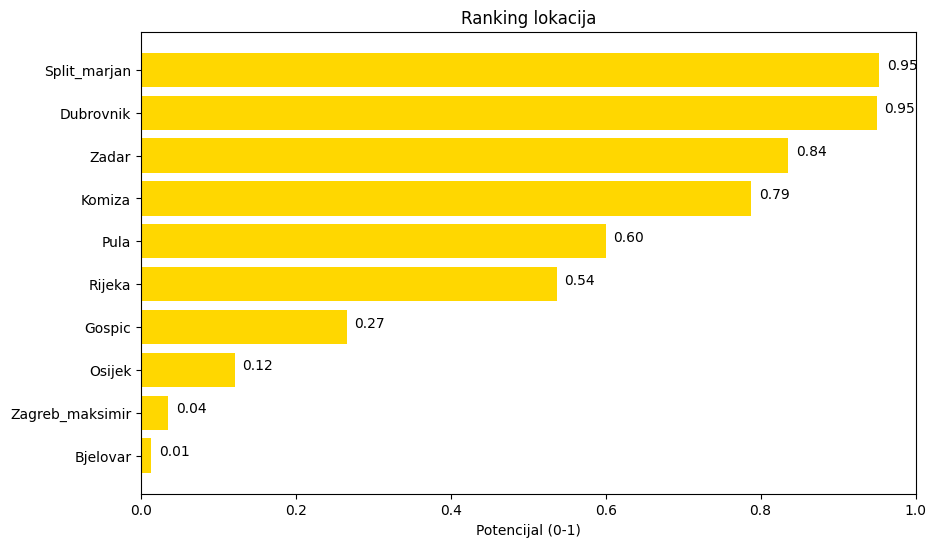

In [ ]:
plt.figure(figsize=(10,6))
df_sorted = df_analiza.sort_values('combined_score', ascending=True)
plt.barh(df_sorted['lokacija'], df_sorted['combined_score'], color='gold')
plt.xlabel('Potencijal (0-1)')
plt.title('Ranking lokacija')
for i, v in enumerate(df_sorted['combined_score']): plt.text(v+0.01, i, f'{v:.2f}')
plt.show()


##Objašnjenje grafa
Graf prikazuje rangiranje lokacija u Hrvatskoj prema kombiniranom potencijalu za korištenje solarne i vjetroenergije, izraženom vrijednostima od 0 do 1. Najveći potencijal imaju lokacije na obali, poput Splita, Dubrovnika i Zadra, što je posljedica velikog broja sunčanih sati i povoljnijih vjetrovnih uvjeta. Srednji potencijal ostvaruju Pula, Rijeka i Komiža, gdje su klimatski uvjeti nešto slabiji, ali i dalje pogodni za razvoj obnovljivih izvora energije. Kontinentalne lokacije poput Osijeka, Zagreba i Bjelovara imaju znatno niže vrijednosti potencijala, prvenstveno zbog manjeg broja sunčanih sati i slabijih vjetrova. Rezultati potvrđuju da su priobalna područja najpogodnija za postavljanje solarnih i vjetroelektrana, dok je u unutrašnjosti potencijal manji. Ovakva analiza omogućuje donošenje informiranih odluka o optimalnom prostornom planiranju obnovljivih izvora energije u Hrvatskoj.

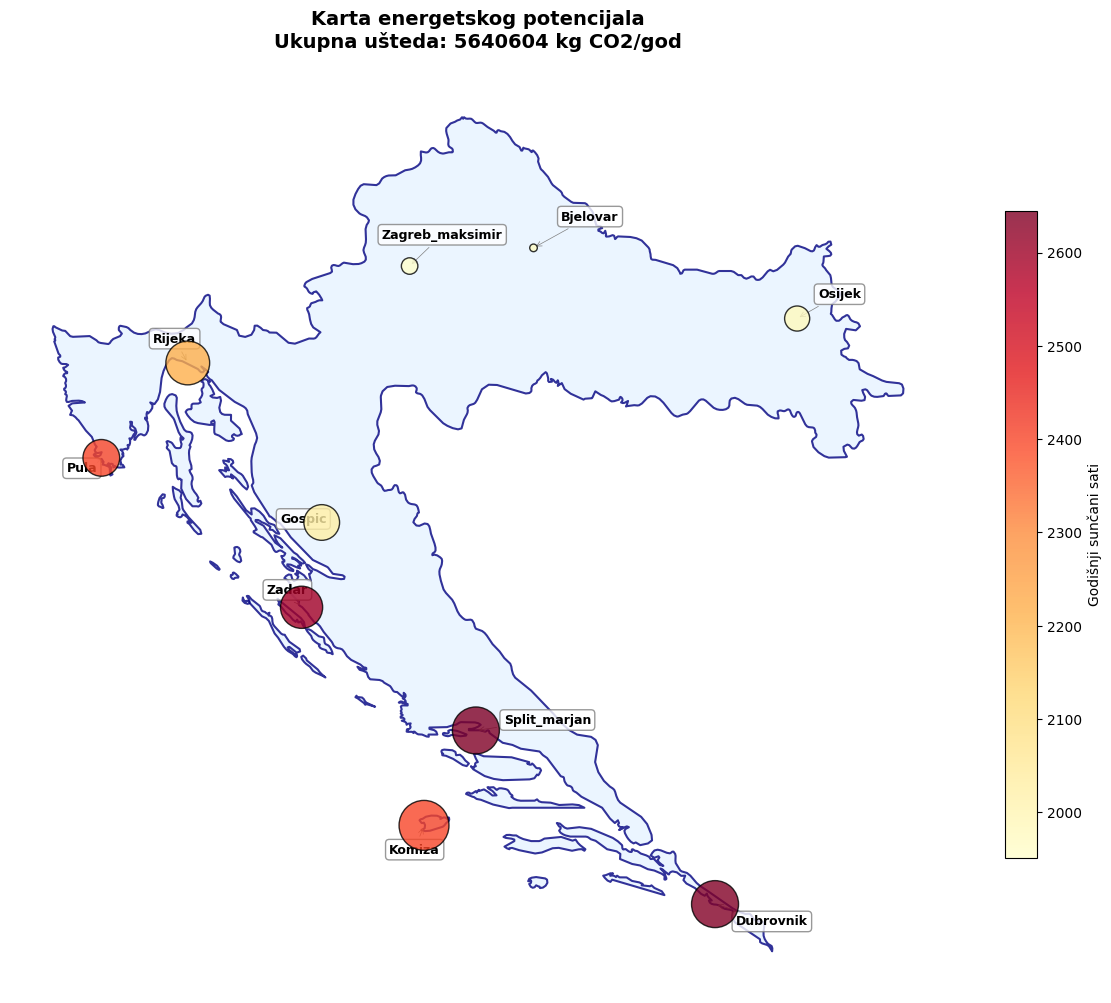

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
koordinate = {
    "Dubrovnik": (18.10, 42.65), "Split_marjan": (16.44, 43.51),
    "Komiza": (16.08, 43.04), "Zadar": (15.23, 44.12),
    "Rijeka": (14.44, 45.33), "Gospic": (15.37, 44.54),
    "Osijek": (18.67, 45.55), "Zagreb_maksimir": (15.98, 45.81),
    "Pula": (13.84, 44.86), "Bjelovar": (16.84, 45.90)
}

df_analiza['coords'] = df_analiza['lokacija'].map(koordinate)
df_analiza['geometry'] = df_analiza['coords'].apply(Point)
gdf_gradovi = gpd.GeoDataFrame(df_analiza, geometry='geometry', crs="EPSG:4326")

url_detaljno = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
world = gpd.read_file(url_detaljno)
croatia = world[world['name'] == 'Croatia']

fig, ax = plt.subplots(figsize=(12, 10))

croatia.plot(ax=ax, color='#e6f3ff', edgecolor='navy', linewidth=1.5, alpha=0.8)

scatter = ax.scatter(gdf_gradovi.geometry.x, gdf_gradovi.geometry.y,
                     s=gdf_gradovi['Usteda_CO2_kg'] / 800 + 30,
                     c=gdf_gradovi['suncani_sati_godisnje'],
                     cmap='YlOrRd',
                     alpha=0.8,
                     edgecolors='black',
                     linewidth=1,
                     zorder=5)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.7, label='Godišnji sunčani sati')

offsets = {
    'Dubrovnik': (15, -15), 'Split_marjan': (20, 5), 'Komiza': (-25, -20),
    'Zadar': (-25, 10), 'Rijeka': (-25, 15), 'Gospic': (-30, 0),
    'Osijek': (15, 15), 'Zagreb_maksimir': (-20, 20), 'Pula': (-25, -10),
    'Bjelovar': (20, 20)
}

for idx, row in gdf_gradovi.iterrows():
    dx, dy = offsets.get(row['lokacija'], (10, 10))
    ax.annotate(row['lokacija'],
                xy=(row.geometry.x, row.geometry.y),
                xytext=(dx, dy),
                textcoords="offset points",
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

plt.title(f'Karta energetskog potencijala\nUkupna ušteda: {df_analiza["Usteda_CO2_kg"].sum():.0f} kg CO2/god',
          fontsize=14, fontweight='bold', pad=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()

##Objašnjenje karte
Karta prikazuje prostornu raspodjelu energetskog potencijala odabranih lokacija u Hrvatskoj. Boja točaka predstavlja godišnji broj sunčanih sati, dok veličina točaka označava procijenjenu uštedu emisija CO₂ koja bi se mogla ostvariti korištenjem solarne i vjetroenergije na pojedinoj lokaciji. Geografski položaji gradova određeni su koordinatama, a karta Hrvatske služi kao prostorni kontekst analize. Vizualizacija omogućuje usporedbu lokacija i identifikaciju područja s najvećim potencijalom za razvoj obnovljivih izvora energije. Ukupna procijenjena ušteda emisija CO₂ prikazana je u naslovu karte kao agregirani rezultat svih analiziranih lokacija.

Text(0.5, 0, 'Sati godišnje')

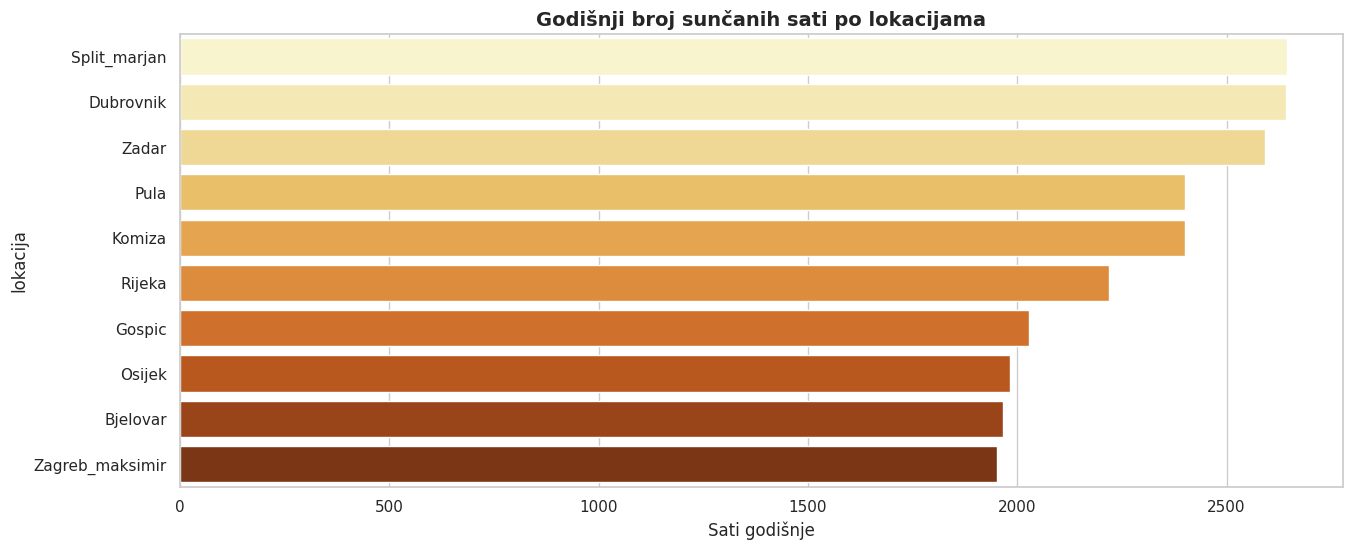

In [ ]:
import seaborn as sns

sns.set(style="whitegrid")
fig = plt.figure(figsize=(15, 20))

ax1 = plt.subplot(3, 1, 1)
colors = sns.color_palette("YlOrRd", len(df_analiza))
df_sorted = df_analiza.sort_values('suncani_sati_godisnje', ascending=False)
sns.barplot(x='suncani_sati_godisnje', y='lokacija', data=df_sorted, palette="YlOrBr", ax=ax1)
ax1.set_title('Godišnji broj sunčanih sati po lokacijama', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sati godišnje')



##Objašnjenje grafa
Grafikon prikazuje usporedbu godišnjeg broja sunčanih sati po odabranim lokacijama u Hrvatskoj. Lokacije su poredane prema vrijednosti sunčanih sati, što omogućuje jednostavnu identifikaciju područja s najvećim solarnim potencijalom. Vidljivo je da obalne i otočne lokacije ostvaruju veći broj sunčanih sati u odnosu na kontinentalne gradove, što je u skladu s klimatskim karakteristikama Hrvatske. Ovaj grafikon služi kao temelj za daljnju analizu energetskog potencijala i procjenu mogućeg doprinosa solarne energije smanjenju emisija CO₂. Rezultati potvrđuju da prostorne razlike u osunčanosti imaju značajan utjecaj na potencijal proizvodnje električne energije iz obnovljivih izvora.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Dubrovnik'),
  Text(1, 0, 'Bjelovar'),
  Text(2, 0, 'Gospic'),
  Text(3, 0, 'Pula'),
  Text(4, 0, 'Osijek'),
  Text(5, 0, 'Rijeka'),
  Text(6, 0, 'Split_marjan'),
  Text(7, 0, 'Komiza'),
  Text(8, 0, 'Zadar'),
  Text(9, 0, 'Zagreb_maksimir')])

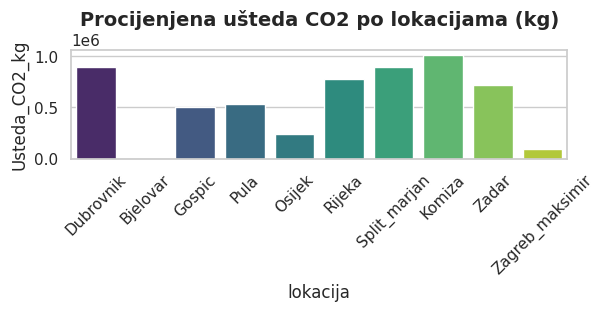

In [ ]:
ax2 = plt.subplot(3, 1, 2)
sns.barplot(x='lokacija', y='Usteda_CO2_kg', data=df_analiza, palette="viridis", ax=ax2)
ax2.set_title('Procijenjena ušteda CO2 po lokacijama (kg)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)

##Objašnjenje grafa
Grafikon prikazuje procijenjenu godišnju uštedu emisija CO₂ po pojedinim lokacijama, izračunatu na temelju potencijala solarne i vjetroenergije. Vrijednosti su dobivene modeliranjem proizvodnje električne energije iz obnovljivih izvora uz korištenje klimatskih podataka o osunčanosti i brzini vjetra. Opet je uočljivo je da obalne i otočne lokacije ostvaruju veće potencijalne uštede CO₂ u odnosu na kontinentalne gradove, što je posljedica povoljnijih klimatskih uvjeta. Grafikon omogućuje usporedbu lokacija i identifikaciju područja s najvećim potencijalom za smanjenje emisija stakleničkih plinova. Rezultati predstavljaju analitičku procjenu, a ne stvarne izmjerene emisije, te služe kao indikativni pokazatelj mogućeg doprinosa obnovljivih izvora energije.

In [ ]:
import folium
from folium import plugins
from google.colab import files

m = folium.Map(location=[44.5, 16.5], zoom_start=7, tiles="OpenStreetMap")

for idx, row in df_analiza.iterrows():
    lat = row['coords'][1]
    lon = row['coords'][0]

    html = f"""
    <div style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; size: 14px;">
        <h4 style="color: #2c3e50; margin-bottom: 5px;">{row['lokacija']}</h4>
        <table style="width: 100%; border-collapse: collapse;">
            <tr><td><b>Sunčani sati:</b></td><td>{row['suncani_sati_godisnje']:.0f} h</td></tr>
            <tr><td><b>Vjetar:</b></td><td>{row['brzina_vjetra']} m/s</td></tr>
            <tr style="color: #27ae60;"><td><b>Ušteda CO2:</b></td><td><b>{row['Usteda_CO2_kg']:.2f} kg</b></td></tr>
        </table>
    </div>
    """

    if row['Solarni_potencijal'] == 1 and row['Vjetro_potencijal'] == 1:
        color_marker = '#2ecc71'
    elif row['Solarni_potencijal'] == 1:
        color_marker = '#3498db'
    else:
        color_marker = '#f39c12'

    folium.CircleMarker(
        location=[lat, lon],
        radius=12,
        popup=folium.Popup(html, max_width=250),
        color=color_marker,
        fill=True,
        fill_color=color_marker,
        fill_opacity=0.7
    ).add_to(m)


ime_datoteke = "energetski_potencijal_RH.html"
m.save(ime_datoteke)

print(f"Karta je uspješno generirana kao {ime_datoteke}!")

files.download(ime_datoteke)

Karta je uspješno generirana kao energetski_potencijal_RH.html!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Objašnjenje karte
Interaktivna karta prikazuje prostornu analizu energetskog potencijala odabranih lokacija u Hrvatskoj na temelju klimatskih podataka o osunčanosti i brzini vjetra. Svaka lokacija označena je kružnim markerom čija boja predstavlja razinu energetskog potencijala: zelena boja označava lokacije s visokim potencijalom za solarne i vjetroelektrane, plava boja lokacije s izraženim solarnim potencijalom, dok narančasta boja označava lokacije s nižim ukupnim potencijalom. Klikom na marker prikazuju se detaljni podaci o godišnjem broju sunčanih sati, prosječnoj brzini vjetra i procijenjenoj godišnjoj uštedi emisija CO₂, izračunatoj na temelju modelirane proizvodnje energije iz obnovljivih izvora. Karta omogućuje vizualnu usporedbu lokacija i identifikaciju područja s najvećim potencijalom za razvoj obnovljivih izvora energije, pri čemu se klimatski podaci povezuju s procjenom mogućeg doprinosa smanjenju emisija stakleničkih plinova. Na taj način interaktivna vizualizacija služi kao alat za donošenje informiranih zaključaka o optimalnim lokacijama za implementaciju solarnih i vjetroenergetskih sustava u Hrvatskoj.

#Zaključak

Rezultati provedene analize pokazuju da klimatski uvjeti u Hrvatskoj značajno variraju po regijama te da ta prostorna heterogenost ima izravan utjecaj na potencijal proizvodnje energije iz obnovljivih izvora. Na temelju integracije podataka o osunčanosti, brzini vjetra i proizvodnje energije, utvrđeno je da obalne i otočne lokacije, poput Splita, Dubrovnika, Zadra i Komiže, ostvaruju najveći kombinirani energetski potencijal, dok kontinentalne lokacije pokazuju umjeren ili niži potencijal. Procijenjena godišnja ušteda emisija CO₂ na analiziranim lokacijama iznosi približno 5640.6  tona, što ukazuje na značajan doprinos koji bi strateško postavljanje solarnih i vjetroelektrana moglo imati na smanjenje ugljičnog otiska.

Analiza također pokazuje da kombinacija solarnih i vjetroenergetskih izvora daje veći učinak od pojedinačnih tehnologija, jer se njihovi proizvodni profili međusobno nadopunjuju. Prostorne vizualizacije i interaktivne karte omogućile su identifikaciju lokacija s najvećim potencijalom te jasno ilustrirale razlike između regija. Time je potvrđeno da podatkovno utemeljen pristup može služiti kao relevantan alat za planiranje energetske tranzicije.

Iako korišteni podaci i parametri predstavljaju aproksimacije, metodologija analize pokazuje kako se kombinacijom klimatskih podataka, energetskih pretpostavki i prostorne analize mogu dobiti smisleni pokazatelji potencijala obnovljivih izvora energije. Ovaj projekt demonstrira da analiza podataka može pružiti kvantitativnu osnovu za donošenje odluka o razvoju obnovljive energetike te ukazuje na važnost korištenja otvorenih podataka u kontekstu održivog razvoja i smanjenja emisija stakleničkih plinova u Republici Hrvatskoj.

Grgo Lalić IPS UIUP 2025./2026.